# AC 209b / CS 1090b MS4 Main Notebook - Project 66

**Team:** Harry Hu, Tom Shan, Wendy Wang, Kemeng Zhang

This notebook is the executed MS4 modeling notebook. It does not launch long training by default. It reads the completed local run artifacts and tracked report-ready summaries, then displays the preprocessing checks, model comparisons, figures, and final interpretation needed for the MS4 submission.

## Runtime and Paths

The notebook is intentionally report-facing: long training and full emotion inference are run from scripts, while this notebook loads their compact outputs. This keeps re-execution fast and makes the displayed outputs deterministic.

In [1]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, Markdown, display

CODE_DIR = Path.cwd()
MS4_DIR = CODE_DIR.parent
PROJECT_ROOT = CODE_DIR.parents[2]
SRC_DIR = CODE_DIR / "src"
REPORT_RESULTS_DIR = MS4_DIR / "report" / "results"
ARTIFACT_DIR = CODE_DIR / "artifacts"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

print(f"CODE_DIR: {CODE_DIR}")
print(f"REPORT_RESULTS_DIR exists: {REPORT_RESULTS_DIR.exists()}")
print(f"Long training blocked in notebook: True")

CODE_DIR: /Users/huziling/Desktop/Harvard/Coursework/2026-01 Spring/AC 209b/Project - Official/milestones/ms4_final_modeling_deliverables/code
REPORT_RESULTS_DIR exists: True
Long training blocked in notebook: True


## Environment Check

This cell records the package and device environment used to read the outputs. MPS availability matters for reproducing the long GRU runs, but not for simply rendering this notebook.

In [2]:
import importlib.metadata as metadata
from ms4mbti.training import torch_environment

packages = ["python", "pandas", "numpy", "scikit-learn", "torch", "transformers", "matplotlib", "seaborn"]
versions = []
for package in packages:
    if package == "python":
        versions.append({"package": package, "version": sys.version.split()[0]})
    else:
        try:
            versions.append({"package": package, "version": metadata.version(package)})
        except metadata.PackageNotFoundError:
            versions.append({"package": package, "version": "not installed"})

display(pd.DataFrame(versions))
display(pd.DataFrame([torch_environment()]))

,package,version
0,python,3.13.9
1,pandas,2.3.3
2,numpy,2.3.4
3,scikit-learn,1.7.2
4,torch,2.10.0
5,transformers,not installed
6,matplotlib,3.10.7
7,seaborn,0.13.2


,torch_available,torch_version,cuda_available,mps_available
0,True,2.10.0,False,True


## Result Artifacts Available to the Notebook

The tracked `report/results` directory contains small CSV and PNG files. Large files such as checkpoints, post-level predictions, and preprocessing parquet caches remain under `code/artifacts/` and are intentionally git-ignored.

In [3]:
result_files = pd.DataFrame(
    [
        {"file": path.name, "bytes": path.stat().st_size}
        for path in sorted(REPORT_RESULTS_DIR.glob("*"))
        if path.is_file()
    ]
)
display(result_files)

,file,bytes
0,README.md,984
1,all_model_metrics.csv,9209
2,bootstrap_model_intervals.csv,1139
3,bootstrap_pairwise_differences.csv,310
4,emotion_distribution_source_vs_reddit.csv,489
5,fig_bootstrap_balanced_accuracy_ci.png,59488
6,fig_emotion_gain_by_target.png,45451
7,fig_final_confusion_matrices.png,61034
8,fig_final_threshold_tuning_curves.png,120327
9,fig_gru_validation_loss.png,59502


## MS4 Pipeline Diagram

This diagram summarizes the implemented path: masked Reddit posts, optional emotion probabilities, Stage 2 post-level prediction, soft author aggregation, and validation-only threshold selection.

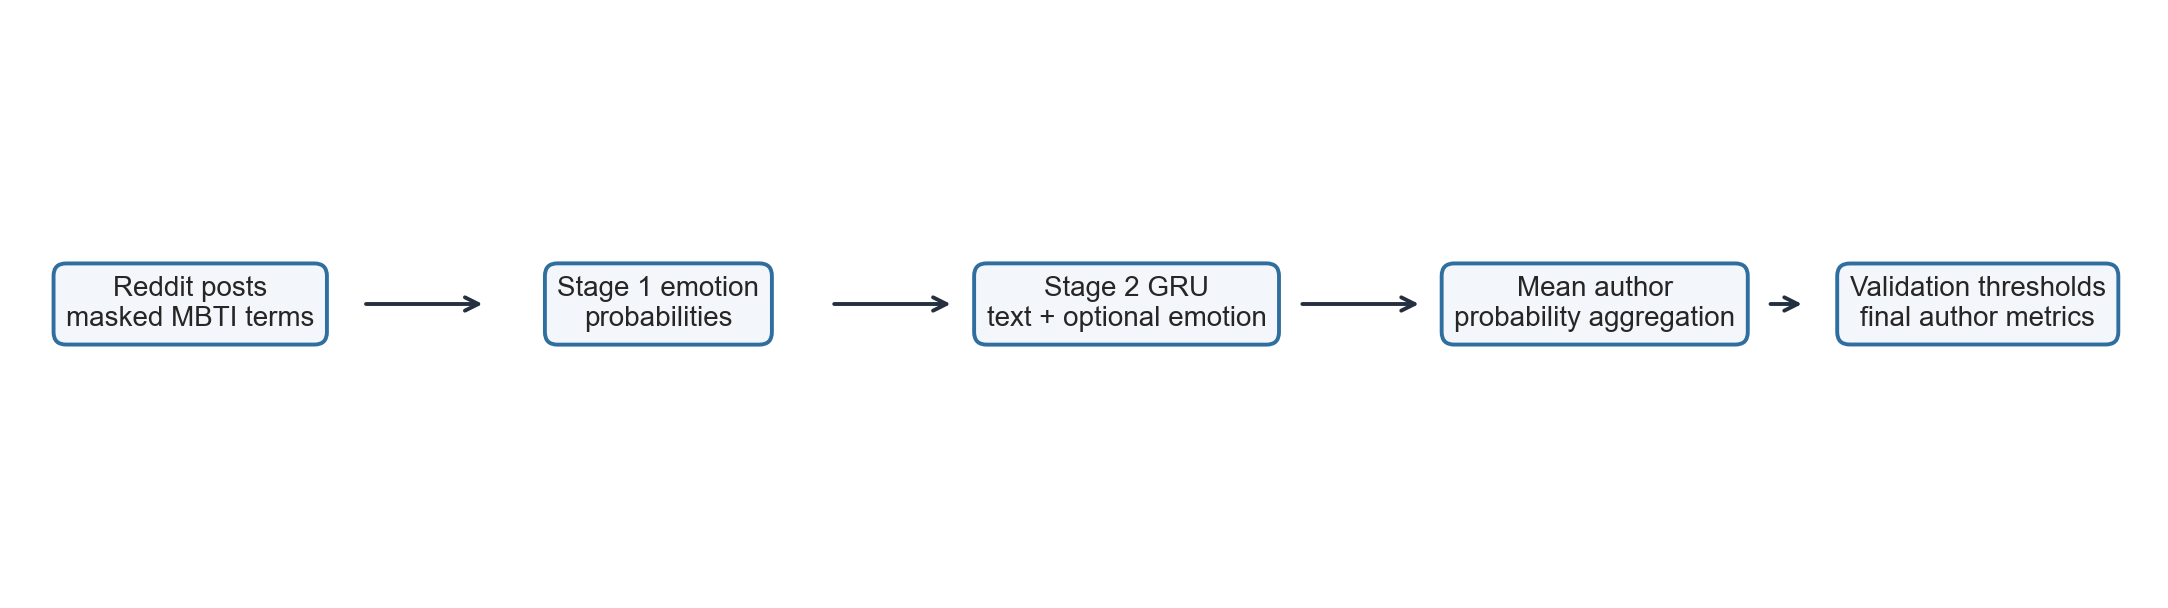

In [4]:
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_ms4_pipeline_diagram.png")))

## Preprocessing Audit

The full local preprocessing run loaded Reddit through KaggleHub, masked explicit MBTI terms, filtered/capped posts using the MS3 rules, and created author-level train/validation/test splits. If the local full preprocessing cache is present, the notebook displays the exact audit outputs; otherwise the tracked report results remain sufficient for model comparison.

In [5]:
pre_dir = ARTIFACT_DIR / "preprocessed" / "full"
summary_path = pre_dir / "summary.json"
leakage_path = pre_dir / "mbti_leakage_audit.csv"
split_balance_path = pre_dir / "split_balance.csv"
token_path = pre_dir / "token_truncation_post_summary.csv"

print(f"Full preprocessing cache present: {pre_dir.exists()}")
if summary_path.exists():
    preprocess_summary = json.loads(summary_path.read_text())
    display(pd.DataFrame([preprocess_summary]))
if leakage_path.exists():
    display(pd.read_csv(leakage_path))
if split_balance_path.exists():
    display(pd.read_csv(split_balance_path))
if token_path.exists():
    display(pd.read_csv(token_path))

Full preprocessing cache present: True


,manifest_fingerprint,n_modeling_authors,n_modeling_posts,output_dir,split_method,split_warnings
0,9f31e43ab502079f,10414,1649102,/Users/huziling/Desktop/Harvard/Coursework/202...,stratified_by_mbti; stratified_by_mbti,[]


,stage,n_posts,n_authors,posts_with_any_term,post_share_with_any_term,authors_with_any_term,author_share_with_any_term,posts_with_own_type,post_share_with_own_type
0,before_masking,13028455,11773,216846,0.016644,9232,0.784167,112294,0.008619
1,after_masking,13028455,11773,0,0.000000,0,0.000000,0,0.000000


,split,target,n_authors,positive_share,positive_count,negative_count
0,test,target_E,1563,0.213692,334,1229
1,test,target_S,1563,0.067179,105,1458
2,test,target_T,1563,0.397313,621,942
3,test,target_J,1563,0.397313,621,942
4,train,target_E,7289,0.213472,1556,5733
5,train,target_S,7289,0.068322,498,6791
6,train,target_T,7289,0.397585,2898,4391
7,train,target_J,7289,0.397037,2894,4395
8,val,target_E,1562,0.213188,333,1229
9,val,target_S,1562,0.069142,108,1454


,n_posts,max_length,median,p90,p95,p99,share_over_max
0,1649102,128,22.0,97.0,147.0,295.0,0.063692


## Token Length Sensitivity

The core Stage 2 GRU uses a 128-token cap. We audit how much text this truncates, then compare a real fixed text-only GRU sensitivity run at 128 vs 256 tokens. The 256-token run is not used as the headline model because it worsened validation loss and collapsed near chance on test balanced accuracy.


,max_length,n_posts,n_authors,median_tokens,p90_tokens,p95_tokens,p99_tokens,share_posts_over_max,share_authors_with_any_truncation
0,128,1649102,10414,22.0,97.0,147.0,295.0,6.37%,90.42%
1,256,1649102,10414,22.0,97.0,147.0,295.0,1.46%,59.62%


,max_length,run_id,epochs_completed,best_val_loss,final_train_loss,test_mean_balanced_accuracy,test_mean_f1,parameter_count
0,128,stage2_text_gru_full,4,0.7200,0.7007,0.5964,0.4225,3947588
1,256,stage2_text_gru_len256_full,3,0.7262,0.7209,0.5029,0.0925,3947588


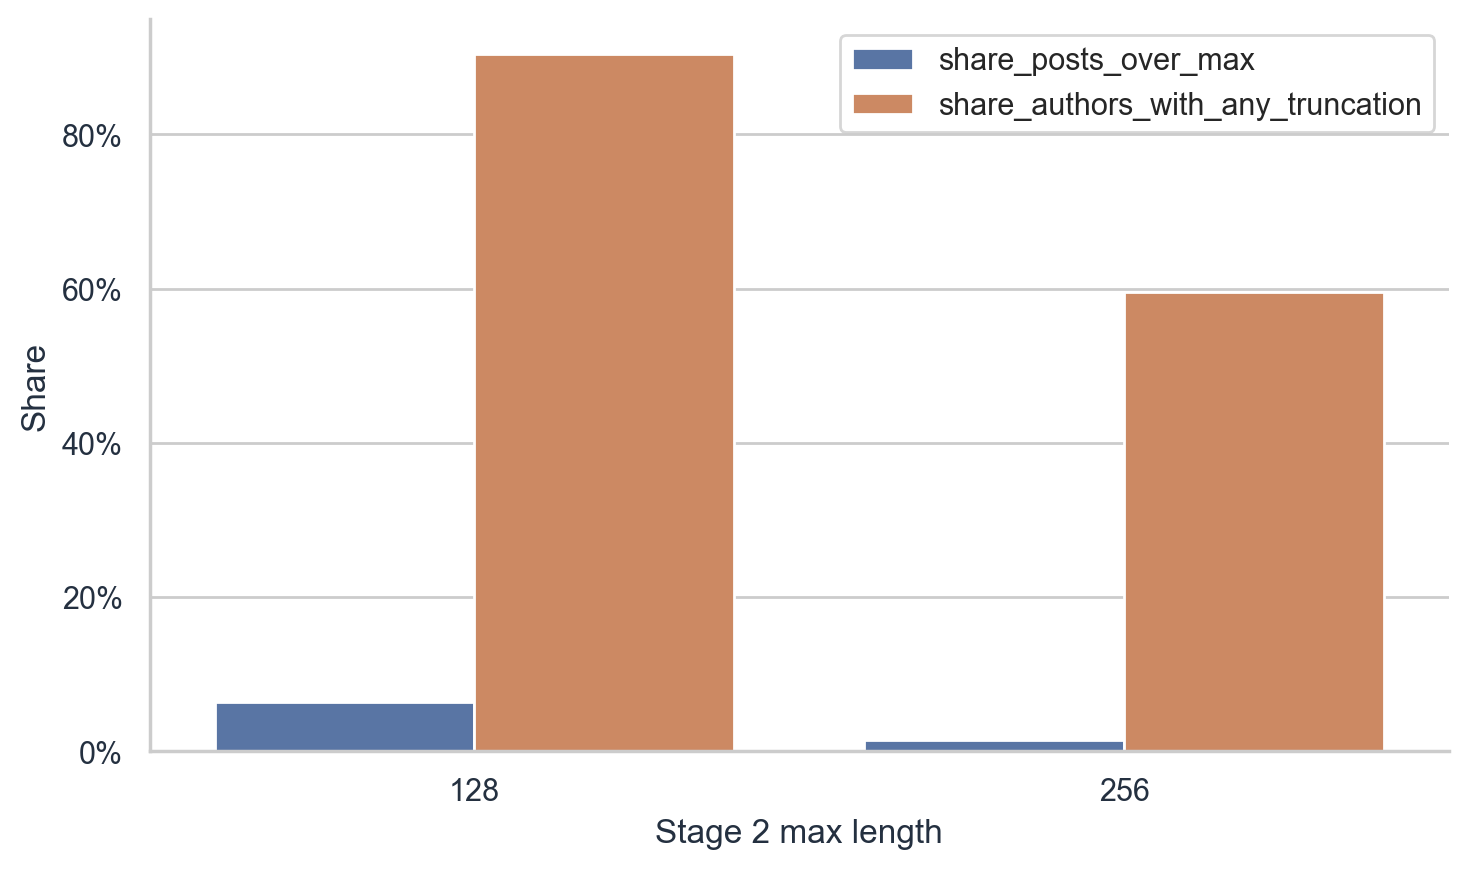

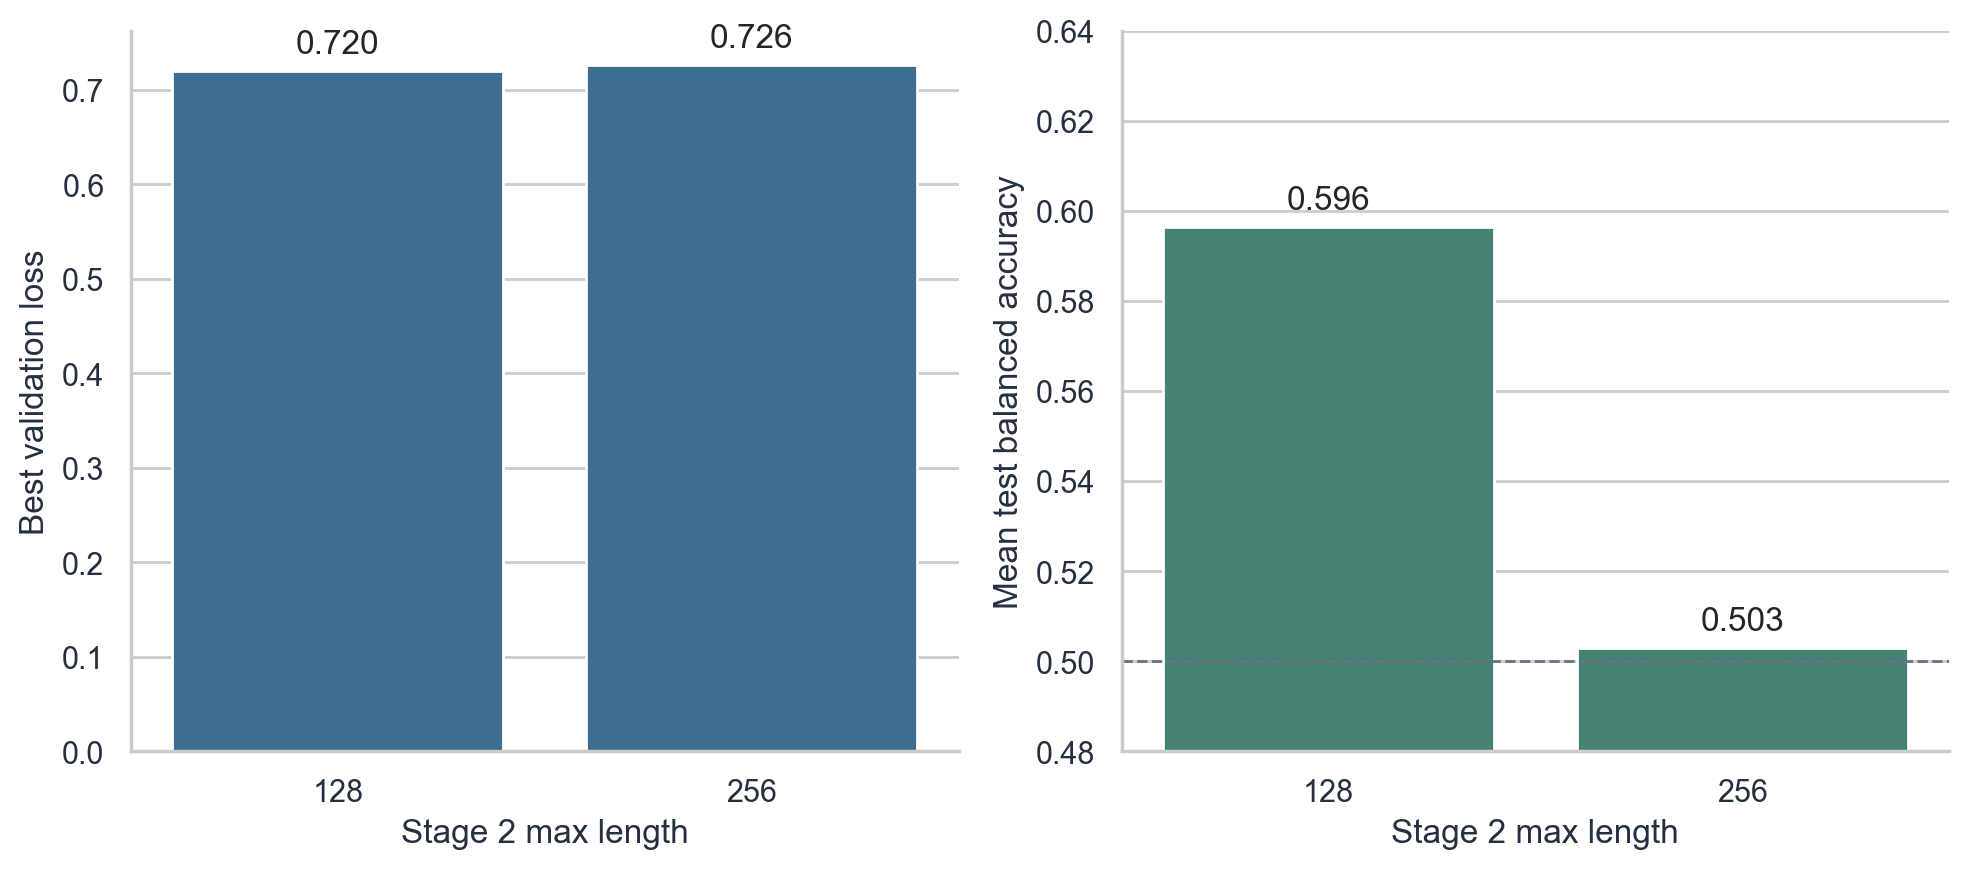

In [6]:
token_length_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "token_length_sensitivity.csv")
max_length_training_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "max_length_training_sensitivity.csv")

display(token_length_sensitivity.style.format({
    "median_tokens": "{:.1f}",
    "p90_tokens": "{:.1f}",
    "p95_tokens": "{:.1f}",
    "p99_tokens": "{:.1f}",
    "share_posts_over_max": "{:.2%}",
    "share_authors_with_any_truncation": "{:.2%}",
}))

display(max_length_training_sensitivity.style.format({
    "best_val_loss": "{:.4f}",
    "final_train_loss": "{:.4f}",
    "test_mean_balanced_accuracy": "{:.4f}",
    "test_mean_f1": "{:.4f}",
}))

display(Image(filename=str(REPORT_RESULTS_DIR / "fig_token_length_sensitivity.png")))
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_max_length_training_sensitivity.png")))


## Model Summary

All metrics are author-level. Thresholds are tuned only on validation authors and then applied once to test authors. The primary metric is mean test balanced accuracy across the four MBTI dimensions.

In [7]:
model_summary = pd.read_csv(REPORT_RESULTS_DIR / "model_summary.csv")
display(model_summary.style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))

,model_id,model_name,balanced_accuracy,f1,minority_recall,roc_auc,average_precision
0,linear_tfidf_author,TF-IDF Logistic,0.6512,0.4609,0.5904,0.7100,0.4643
1,stage2_text_emotion_gru,GRU Text + Emotion,0.6223,0.4336,0.5904,0.6833,0.4451
2,stage2_text_gru_sqrt,GRU Text,0.5964,0.4225,0.6318,0.6591,0.4132
3,stage2_text_gru_inverse,GRU Text Inverse Weight,0.5855,0.3972,0.5546,0.6265,0.3821
4,majority_author,Majority,0.5000,0.0000,0.0000,0.5000,0.2689


## Per-Dimension Test Metrics

This table shows where each model succeeds or fails. The emotion-informed GRU improves over the text-only GRU on every dimension except the text-only model's minority recall advantage on some targets, but the author-level TF-IDF logistic baseline remains strongest overall.

In [8]:
all_metrics = pd.read_csv(REPORT_RESULTS_DIR / "all_model_metrics.csv")
test_metrics = all_metrics.loc[all_metrics["split"] == "test"].copy()
cols = ["model_name", "target", "balanced_accuracy", "f1", "minority_recall", "roc_auc", "average_precision"]
display(test_metrics[cols].sort_values(["target", "balanced_accuracy"], ascending=[True, False]).style.format({
    "balanced_accuracy": "{:.4f}",
    "f1": "{:.4f}",
    "minority_recall": "{:.4f}",
    "roc_auc": "{:.4f}",
    "average_precision": "{:.4f}",
}))

,model_name,target,balanced_accuracy,f1,minority_recall,roc_auc,average_precision
12,TF-IDF Logistic,target_E,0.6694,0.4675,0.6138,0.7331,0.4312
36,GRU Text + Emotion,target_E,0.6119,0.4004,0.5599,0.6777,0.3831
20,GRU Text,target_E,0.5958,0.3795,0.5000,0.6528,0.3427
28,GRU Text Inverse Weight,target_E,0.5890,0.3764,0.5449,0.6325,0.3190
4,Majority,target_E,0.5000,0.0000,0.0000,0.5000,0.2137
15,TF-IDF Logistic,target_J,0.6271,0.5381,0.5121,0.6845,0.5941
39,GRU Text + Emotion,target_J,0.6191,0.5484,0.5652,0.6680,0.5842
23,GRU Text,target_J,0.5656,0.5498,0.7150,0.6095,0.5056
31,GRU Text Inverse Weight,target_J,0.5606,0.4587,0.4428,0.5850,0.4731
7,Majority,target_J,0.5000,0.0000,0.0000,0.5000,0.3973


## Figure 1: Overall Model Ranking

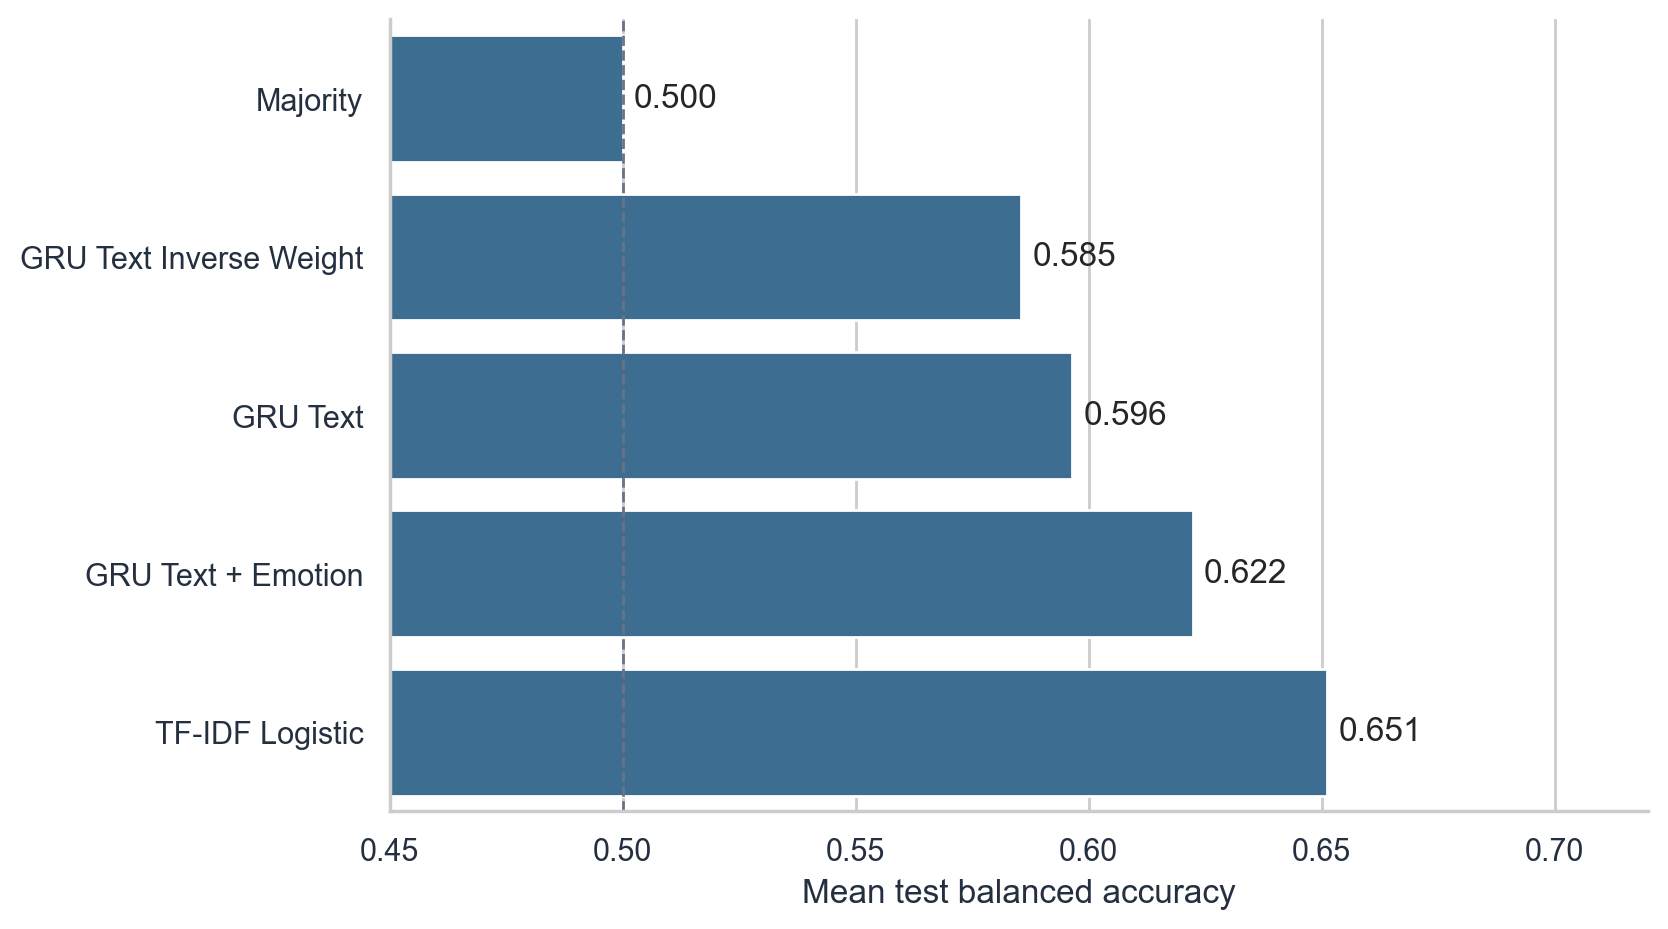

In [9]:
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_model_summary_balanced_accuracy.png")))

## Bootstrap Confidence Intervals

We bootstrap test authors to estimate uncertainty around the mean balanced accuracy. The paired bootstrap difference is most relevant for the main emotion question because it compares the fixed text-only GRU and the text-plus-emotion GRU under the same split and aggregation protocol.


,model_name,point_estimate,ci_lower,ci_upper,n_test_authors,n_bootstrap
2,TF-IDF Logistic,0.6512,0.6341,0.6673,1563,2000
8,GRU Text + Emotion,0.6223,0.6048,0.6398,1563,2000
4,GRU Text,0.5964,0.5802,0.6142,1563,2000
6,GRU Text Inverse Weight,0.5855,0.5689,0.6032,1563,2000
0,Majority,0.5000,0.5000,0.5000,1563,2000


,comparison,metric,point_estimate,ci_lower,ci_upper,n_bootstrap
0,GRU Text + Emotion minus GRU Text,balanced_accuracy,+0.0258,+0.0022,+0.0496,2000
1,TF-IDF Logistic minus GRU Text + Emotion,balanced_accuracy,+0.0283,+0.0051,+0.0529,2000


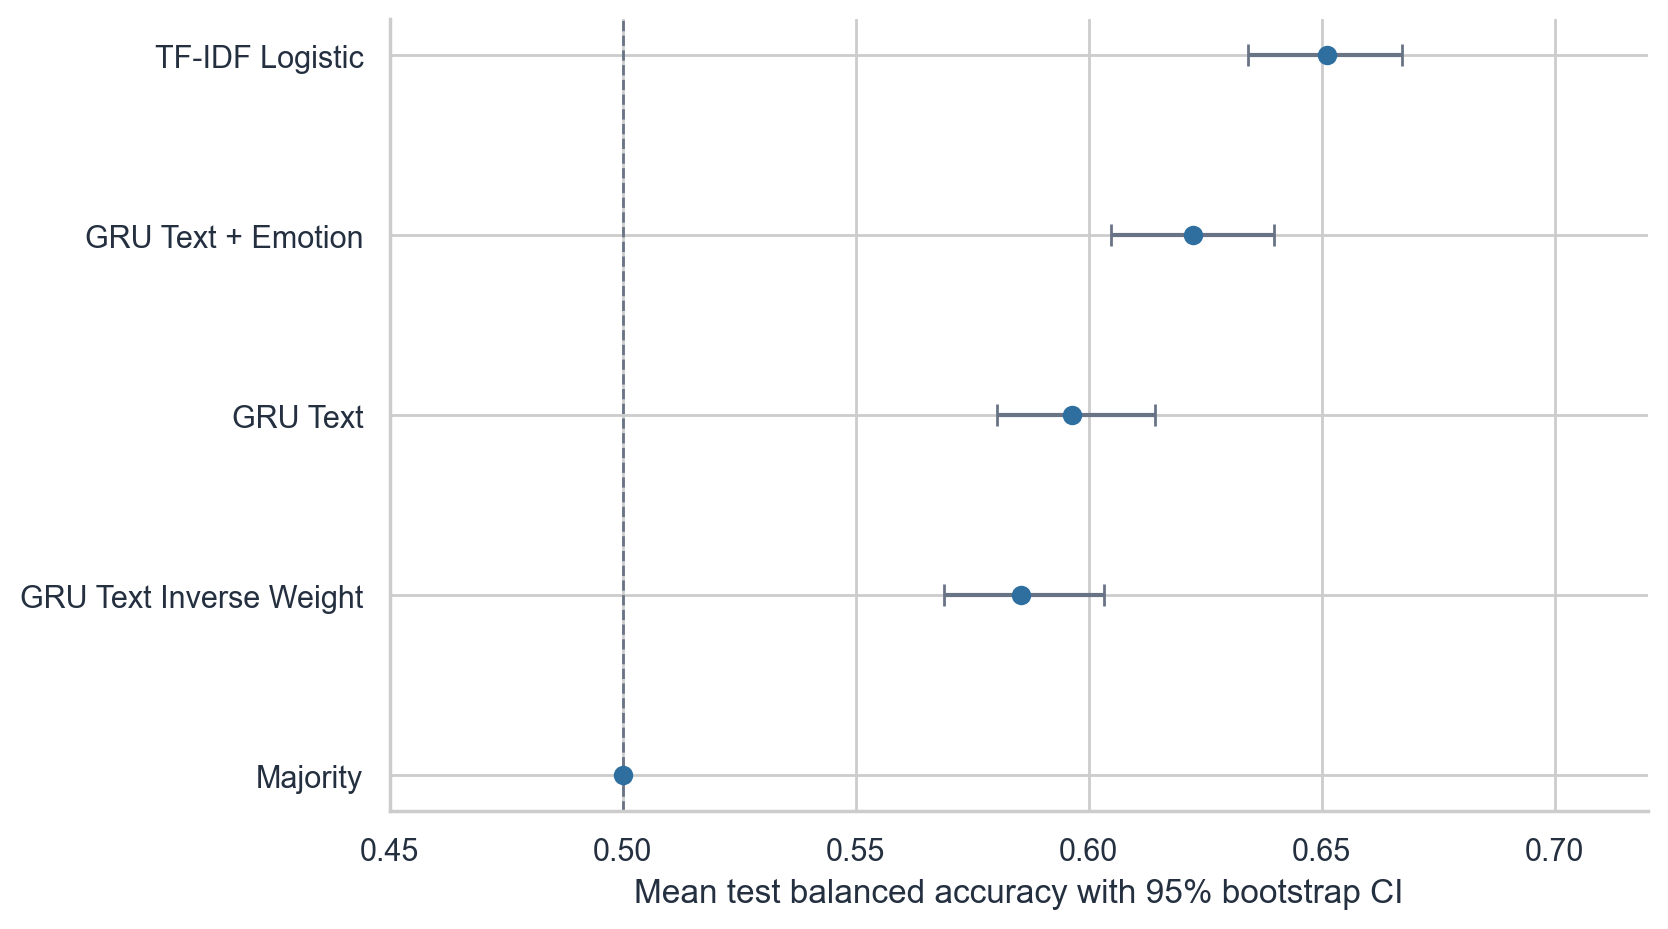

In [10]:
bootstrap_intervals = pd.read_csv(REPORT_RESULTS_DIR / "bootstrap_model_intervals.csv")
bootstrap_differences = pd.read_csv(REPORT_RESULTS_DIR / "bootstrap_pairwise_differences.csv")

balanced_accuracy_ci = bootstrap_intervals.loc[
    bootstrap_intervals["metric"] == "balanced_accuracy",
    ["model_name", "point_estimate", "ci_lower", "ci_upper", "n_test_authors", "n_bootstrap"],
].sort_values("point_estimate", ascending=False)

display(balanced_accuracy_ci.style.format({
    "point_estimate": "{:.4f}",
    "ci_lower": "{:.4f}",
    "ci_upper": "{:.4f}",
}))

display(bootstrap_differences.style.format({
    "point_estimate": "{:+.4f}",
    "ci_lower": "{:+.4f}",
    "ci_upper": "{:+.4f}",
}))

display(Image(filename=str(REPORT_RESULTS_DIR / "fig_bootstrap_balanced_accuracy_ci.png")))


## Figure 2: Per-Dimension Balanced Accuracy

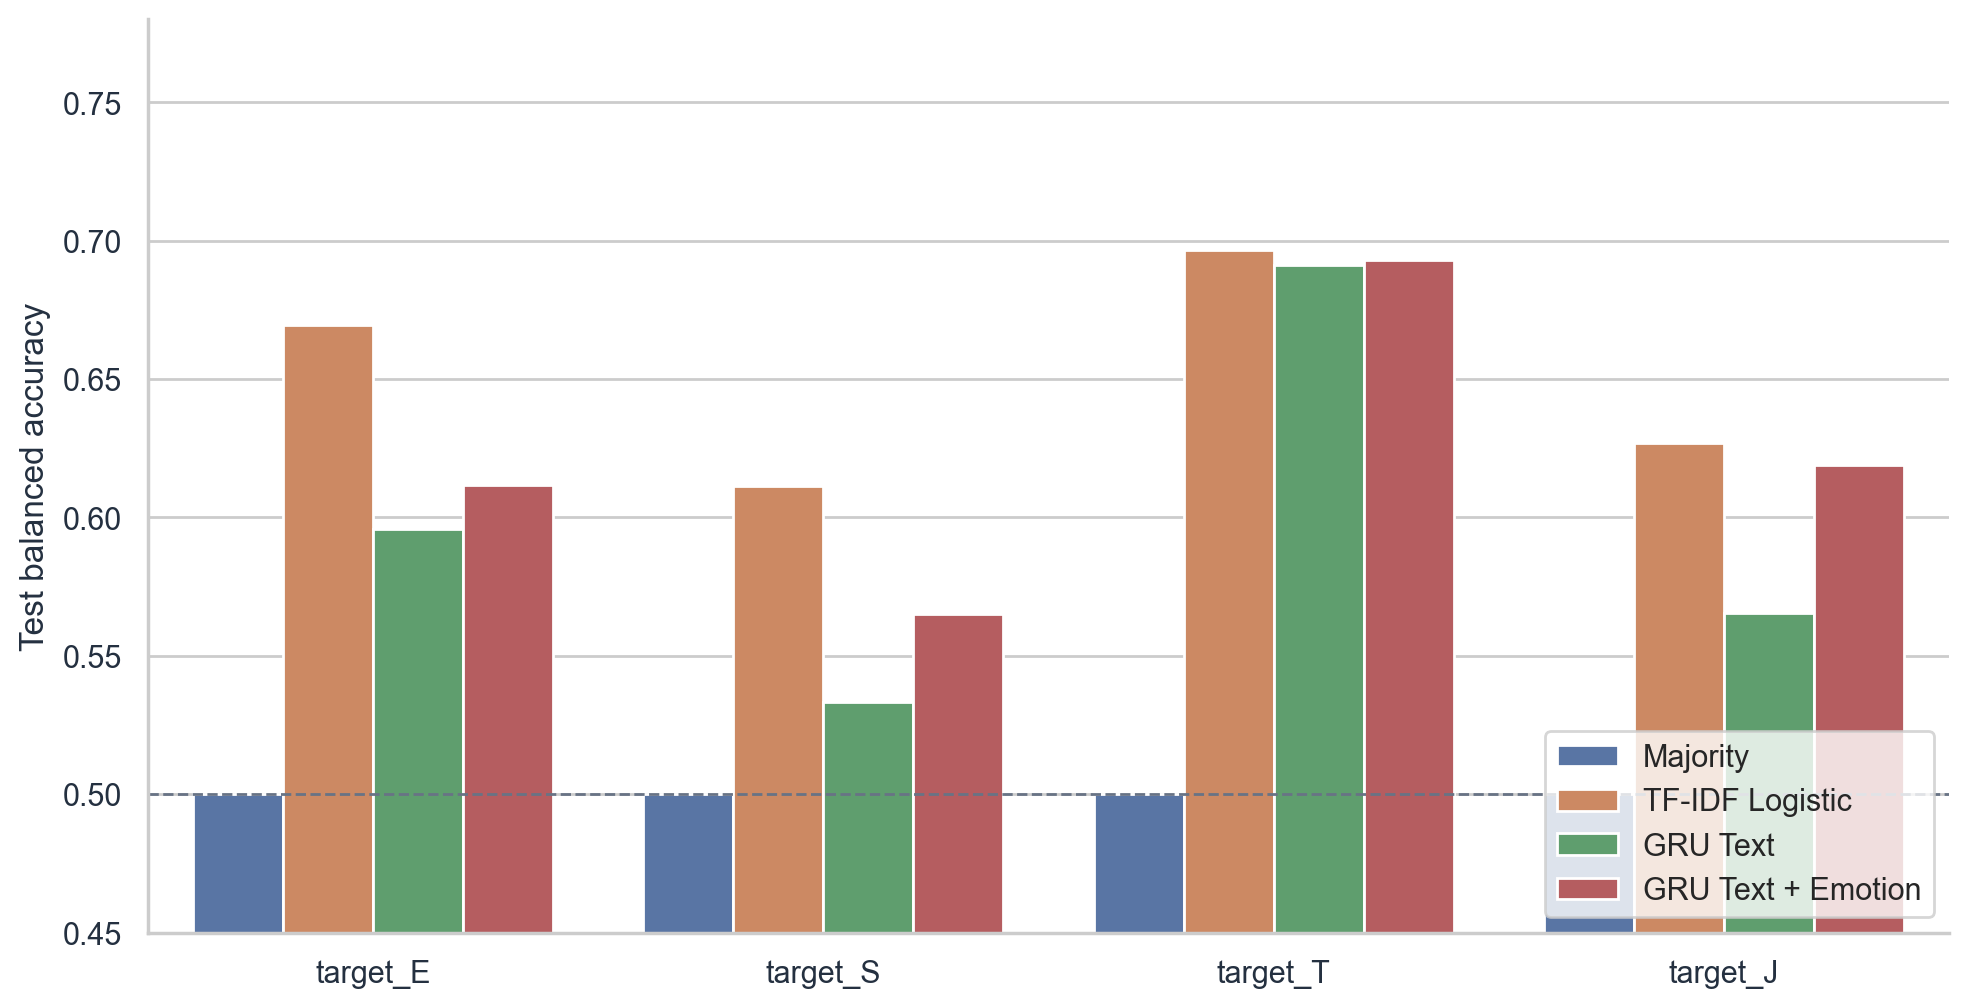

In [11]:
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_target_balanced_accuracy.png")))

## Figure 3: Emotion Feature Gain

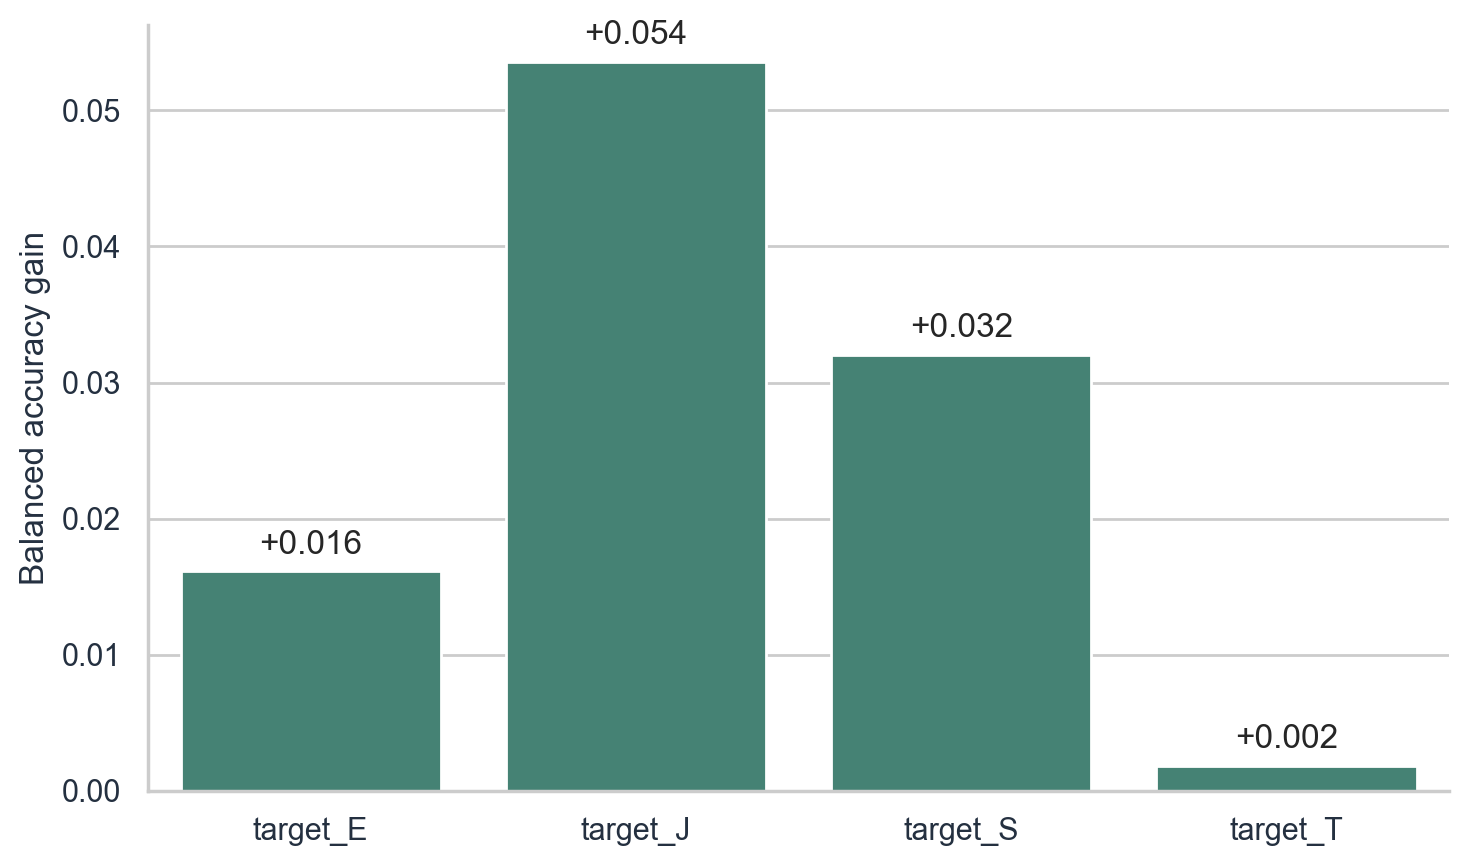

In [12]:
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_emotion_gain_by_target.png")))

## Source-vs-Reddit Emotion Distribution

The source emotion dataset is intentionally balanced. The inferred Reddit distribution is not balanced: joy and anger dominate under the transferred classifier. This is useful context for interpreting why emotion features help but do not dominate the lexical baseline.

,source,emotion,share
0,Emotion source labels,sadness,0.167
1,Emotion source labels,joy,0.167
2,Emotion source labels,love,0.167
3,Emotion source labels,anger,0.167
4,Emotion source labels,fear,0.167
5,Emotion source labels,surprise,0.167
6,Reddit inferred,sadness,0.113
7,Reddit inferred,joy,0.496
8,Reddit inferred,love,0.025
9,Reddit inferred,anger,0.274


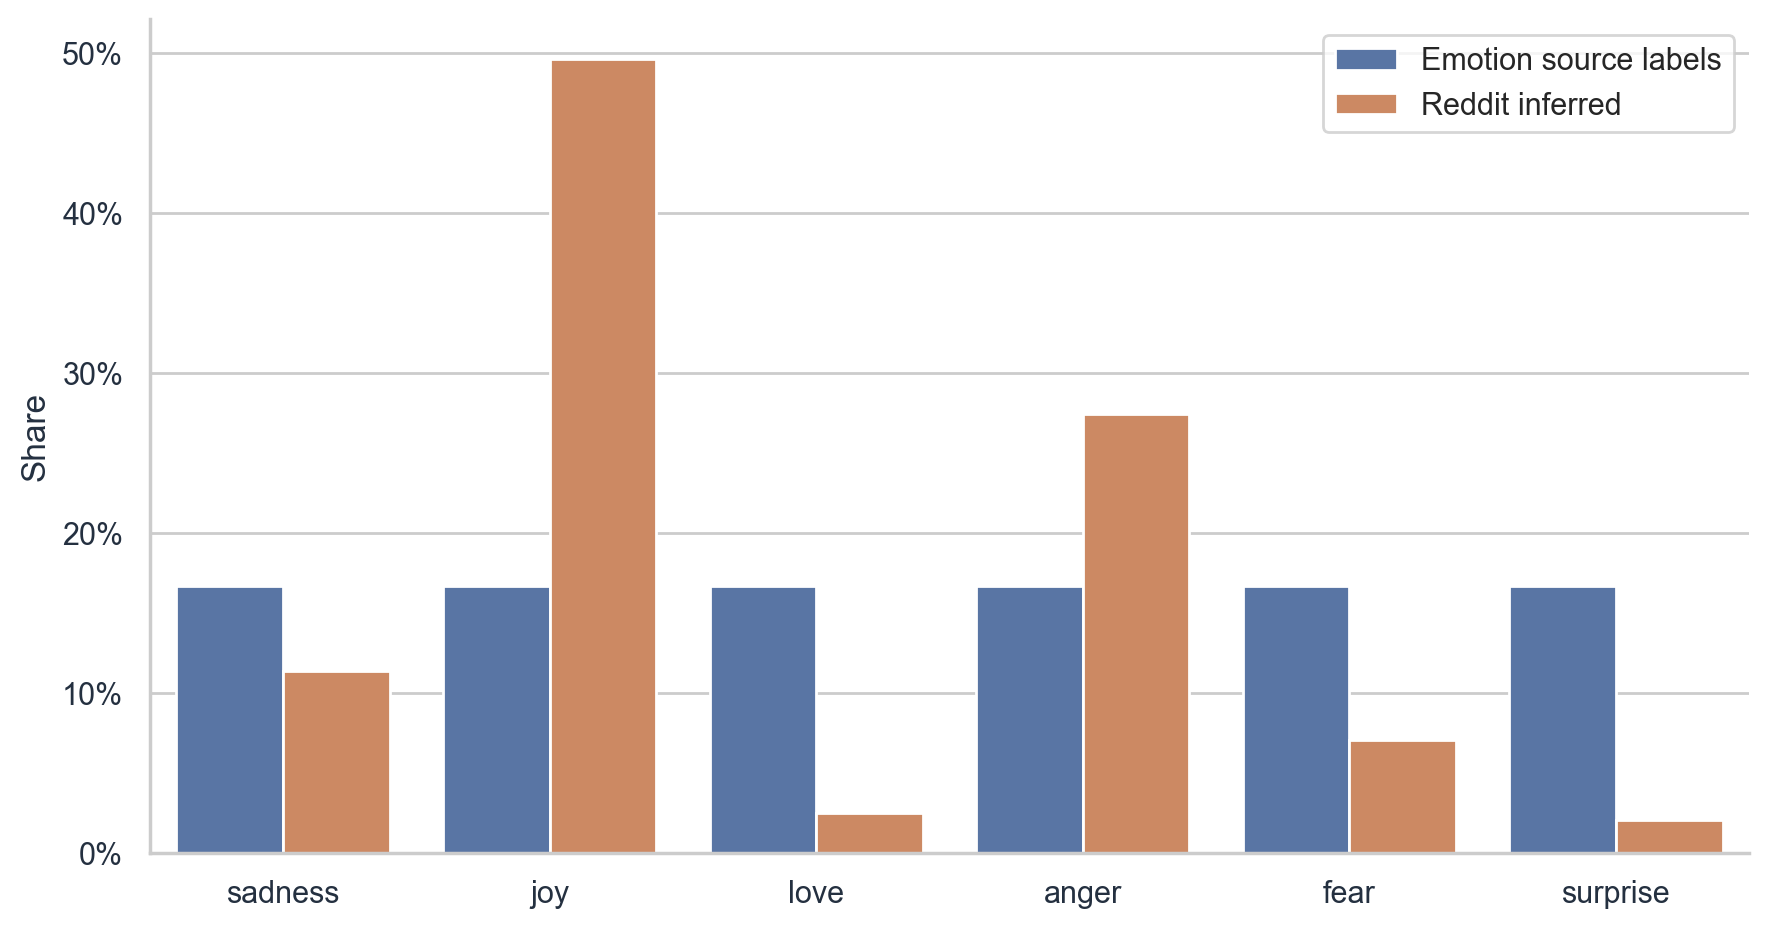

In [13]:
emotion_dist = pd.read_csv(REPORT_RESULTS_DIR / "emotion_distribution_source_vs_reddit.csv")
display(emotion_dist.style.format({"share": "{:.3f}"}))
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_source_vs_reddit_emotion_distribution.png")))

## GRU Training Curves

The curves below show validation loss for the GRU variants. Early stopping selected the best checkpoint before final test evaluation.

,epoch,train_loss,val_loss,model_id,model_name
0,1,0.7221,0.7242,stage2_text_gru_sqrt,GRU Text
1,2,0.7149,0.7200,stage2_text_gru_sqrt,GRU Text
2,3,0.7081,0.7204,stage2_text_gru_sqrt,GRU Text
3,4,0.7007,0.7239,stage2_text_gru_sqrt,GRU Text
4,1,1.0132,1.0196,stage2_text_gru_inverse,GRU Text Inverse Weight
5,2,1.0129,1.0196,stage2_text_gru_inverse,GRU Text Inverse Weight
6,3,1.0118,1.0194,stage2_text_gru_inverse,GRU Text Inverse Weight
7,4,1.0069,1.0174,stage2_text_gru_inverse,GRU Text Inverse Weight
8,5,0.9967,1.0186,stage2_text_gru_inverse,GRU Text Inverse Weight
9,6,0.9854,1.0255,stage2_text_gru_inverse,GRU Text Inverse Weight


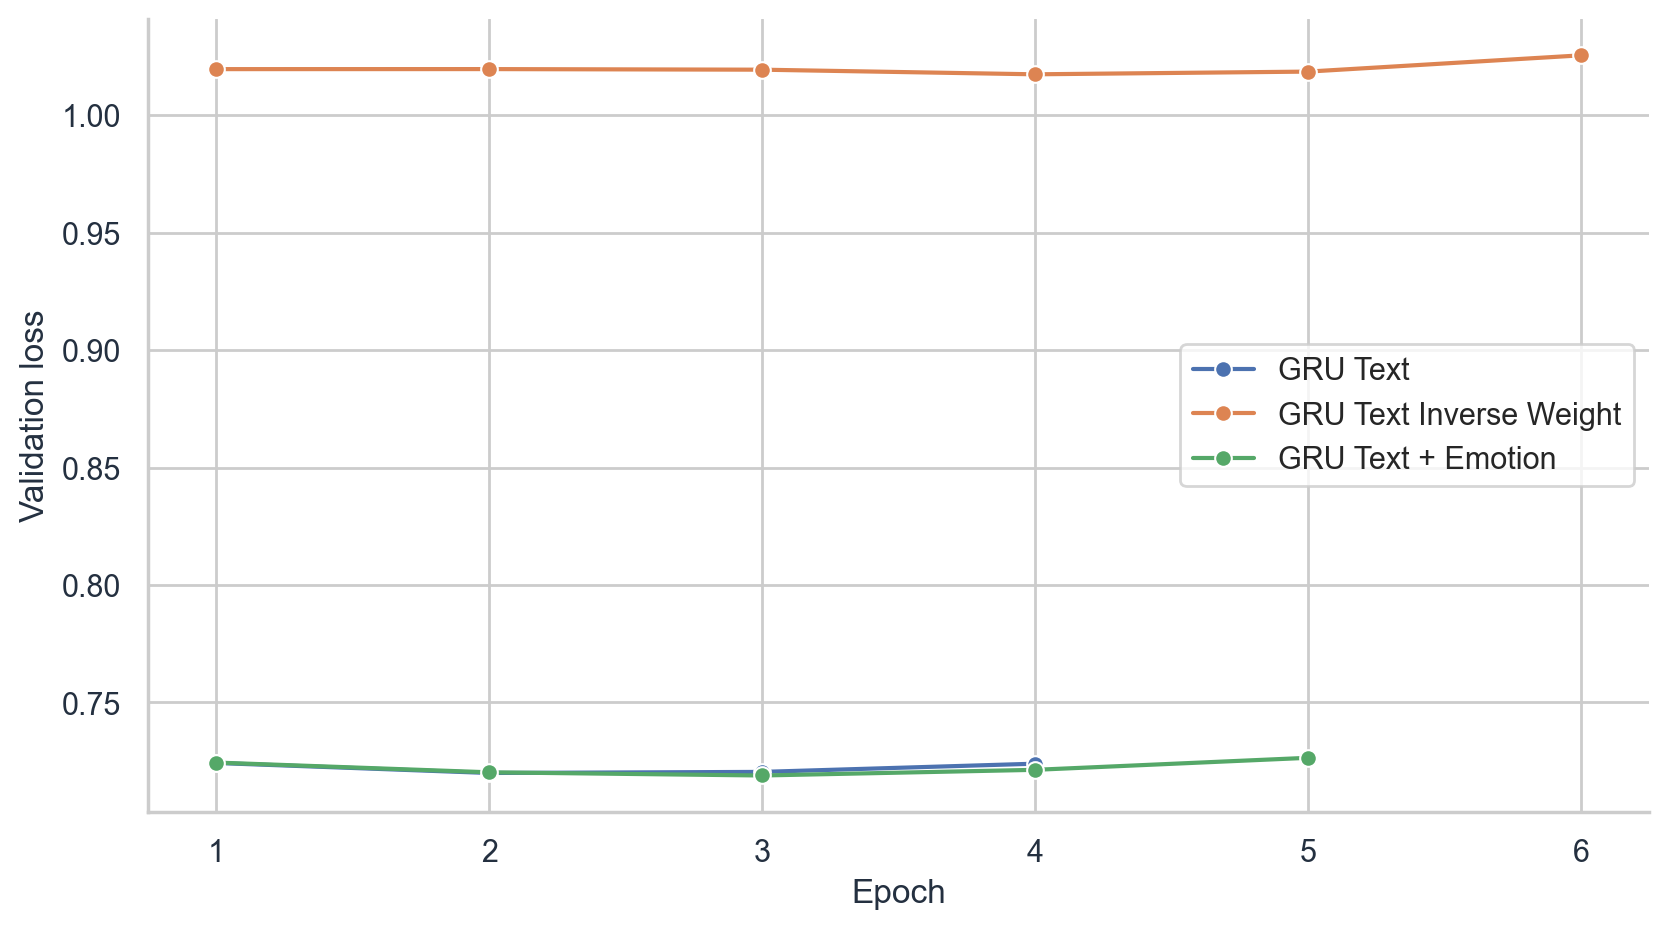

In [14]:
histories = pd.read_csv(REPORT_RESULTS_DIR / "gru_training_histories.csv")
display(histories.style.format({"train_loss": "{:.4f}", "val_loss": "{:.4f}"}))
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_gru_validation_loss.png")))

## Final Model Threshold Tuning

Thresholds are tuned on validation authors only. The red vertical lines show the selected thresholds for the final text+emotion GRU before applying them once to the test split.

,target,threshold,balanced_accuracy,f1
60,target_E,0.350,0.6466,0.4388
622,target_J,0.445,0.6158,0.5459
214,target_S,0.215,0.6117,0.1753
443,target_T,0.455,0.7047,0.6524


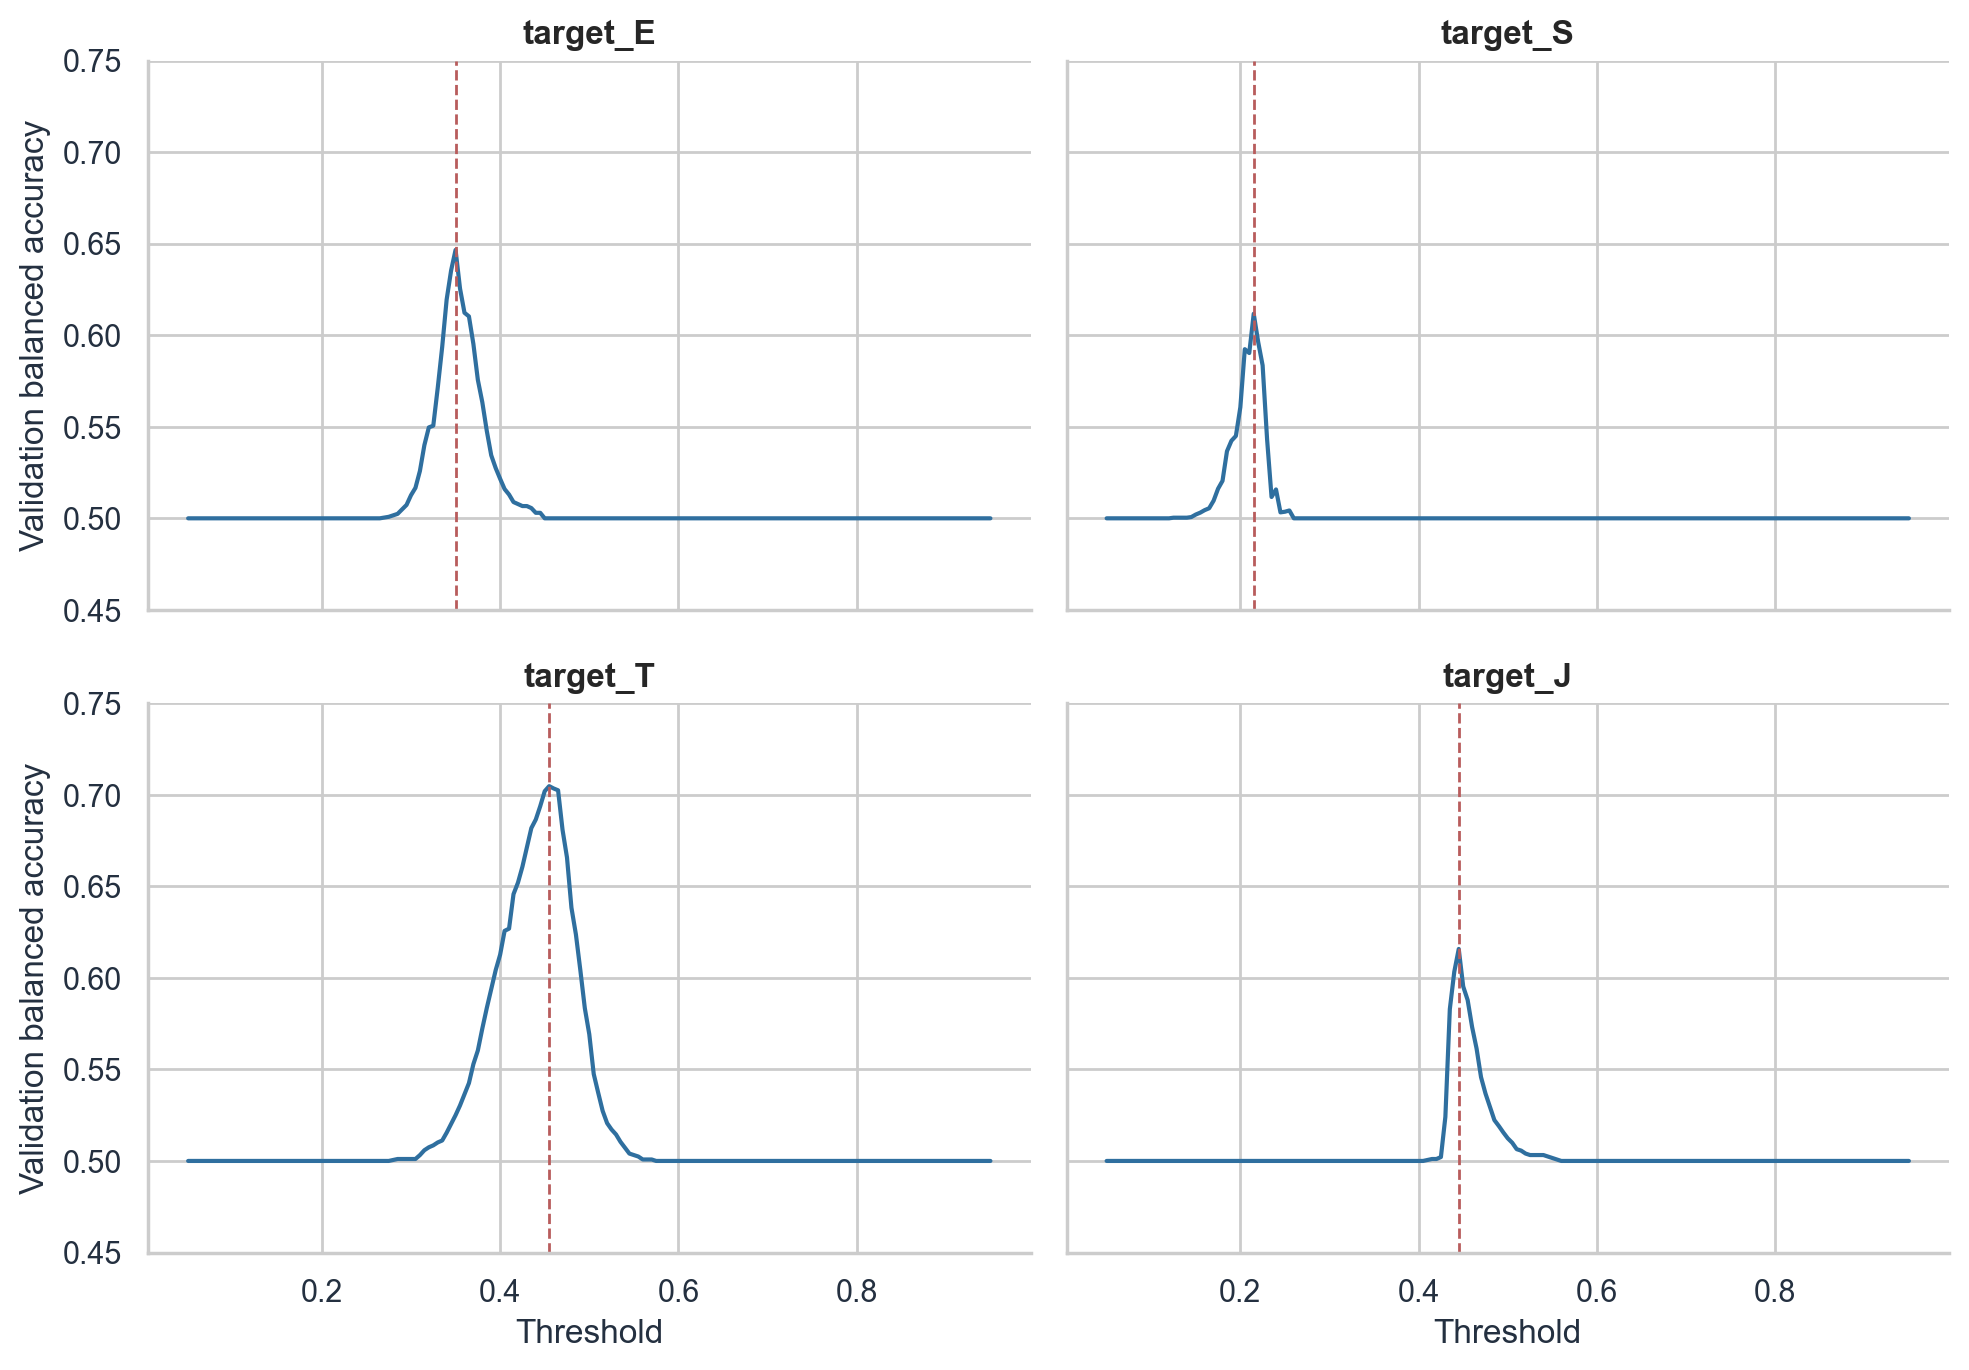

In [15]:
threshold_curves = pd.read_csv(REPORT_RESULTS_DIR / "final_threshold_tuning_curves.csv")
best_threshold_rows = (
    threshold_curves.sort_values(["target", "balanced_accuracy"], ascending=[True, False])
    .groupby("target", as_index=False)
    .head(1)[["target", "threshold", "balanced_accuracy", "f1"]]
    .sort_values("target")
)
display(best_threshold_rows.style.format({"threshold": "{:.3f}", "balanced_accuracy": "{:.4f}", "f1": "{:.4f}"}))
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_final_threshold_tuning_curves.png")))

## Threshold Objective Sensitivity

The primary threshold objective is validation balanced accuracy. As a robustness check, we also tune thresholds for validation F1 and compare the resulting test metrics. This checks that the final conclusion is not just an artifact of an arbitrary threshold objective.


,target,threshold_objective,selected_threshold,validation_objective_score,test_balanced_accuracy,test_f1
0,target_E,balanced_accuracy,0.350,0.6466,0.6119,0.4004
1,target_E,f1,0.350,0.4388,0.6119,0.4004
2,target_S,balanced_accuracy,0.215,0.6117,0.5652,0.1485
3,target_S,f1,0.225,0.1951,0.5641,0.1688
4,target_T,balanced_accuracy,0.455,0.7047,0.6929,0.6369
5,target_T,f1,0.450,0.6570,0.6993,0.6520
6,target_J,balanced_accuracy,0.445,0.6158,0.6191,0.5484
7,target_J,f1,0.435,0.5970,0.5729,0.5900


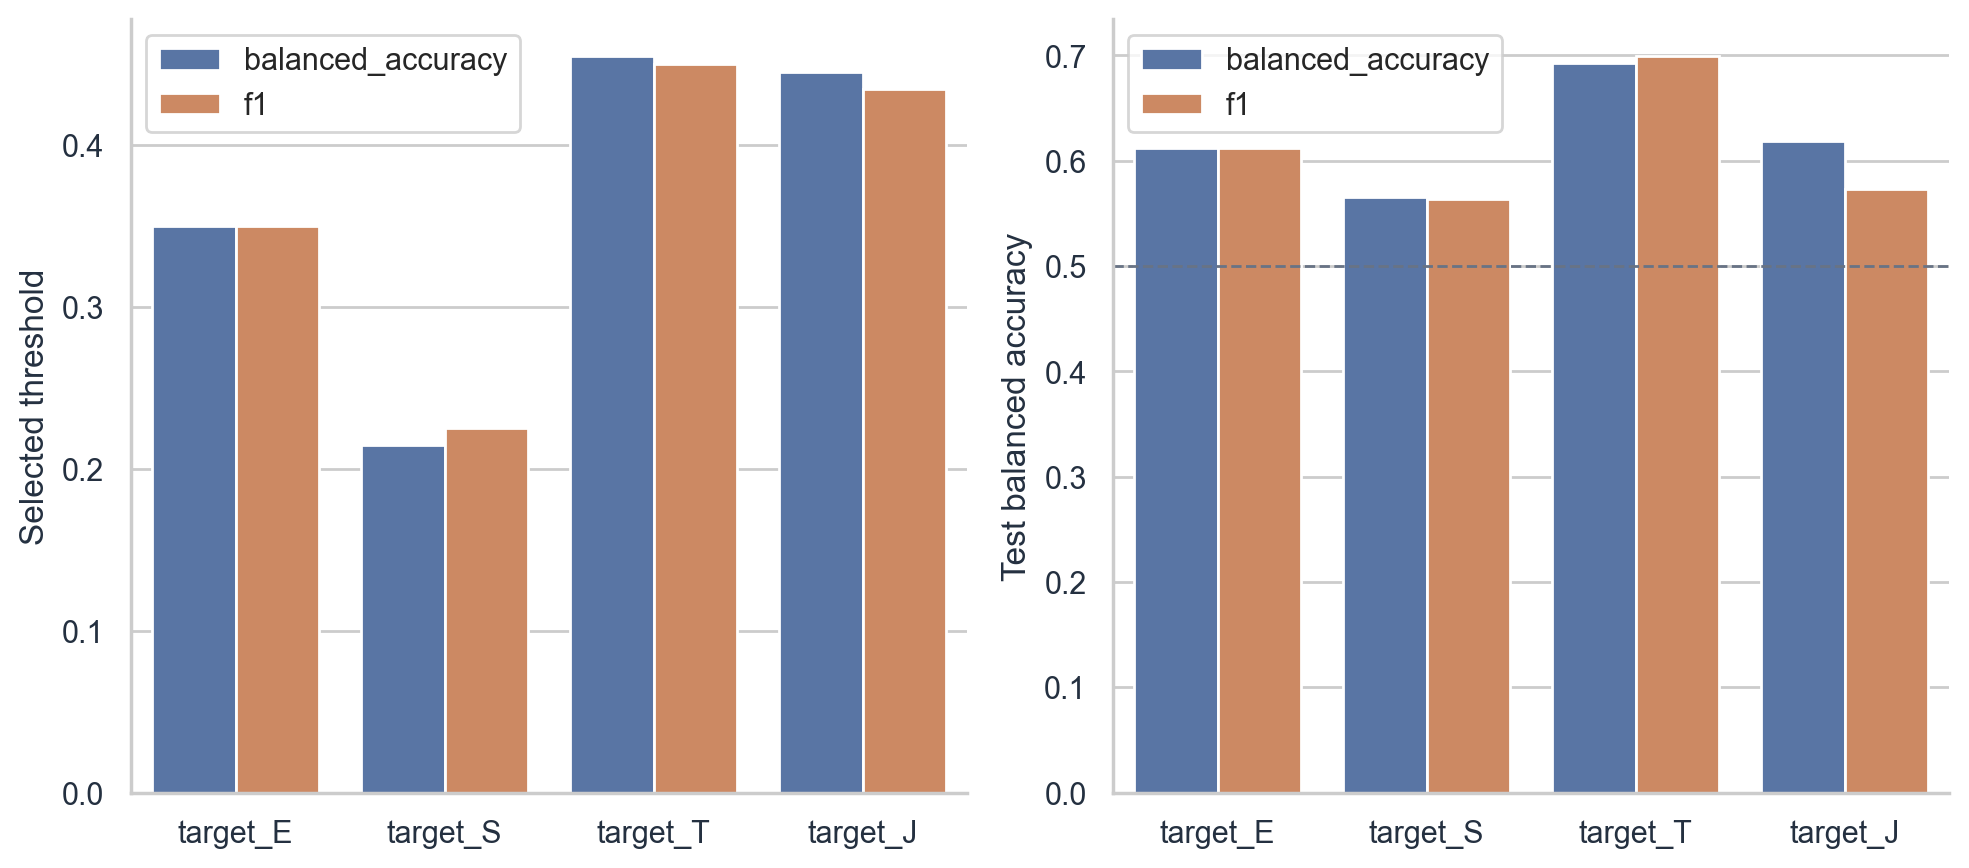

In [16]:
threshold_sensitivity = pd.read_csv(REPORT_RESULTS_DIR / "threshold_objective_sensitivity.csv")
display(threshold_sensitivity.style.format({
    "selected_threshold": "{:.3f}",
    "validation_objective_score": "{:.4f}",
    "test_balanced_accuracy": "{:.4f}",
    "test_f1": "{:.4f}",
}))
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_threshold_objective_sensitivity.png")))


## Final Model Confusion Matrices

These confusion matrices use the final text+emotion GRU on test authors. They make the class-imbalance tradeoff visible, especially for the rare `target_S` positive class.

,target,true_label,predicted_label,count
0,target_E,0,0,816
1,target_E,0,1,413
2,target_E,1,0,147
3,target_E,1,1,187
4,target_S,0,0,815
5,target_S,0,1,643
6,target_S,1,0,45
7,target_S,1,1,60
8,target_T,0,0,679
9,target_T,0,1,263


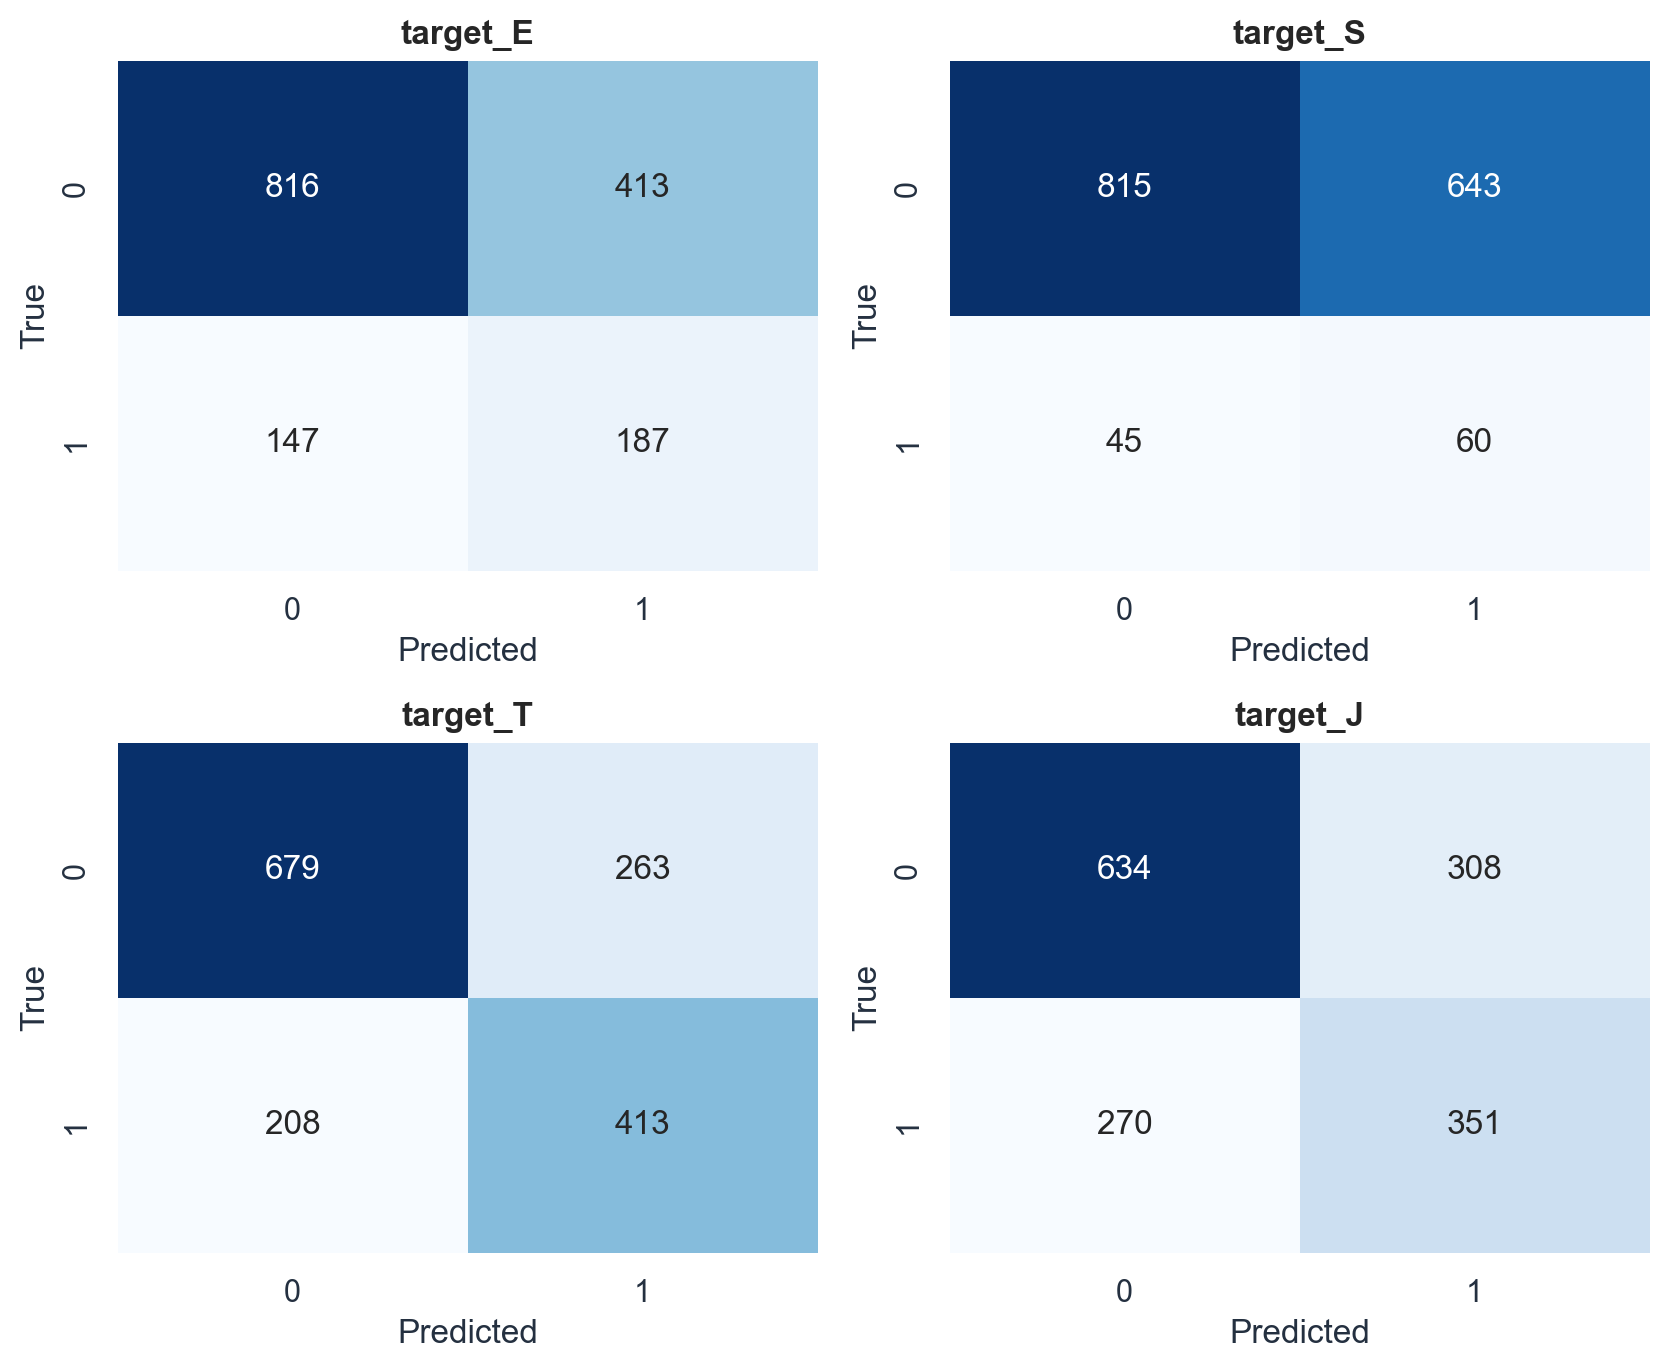

In [17]:
confusions = pd.read_csv(REPORT_RESULTS_DIR / "final_confusion_matrices.csv")
display(confusions)
display(Image(filename=str(REPORT_RESULTS_DIR / "fig_final_confusion_matrices.png")))

## Run-Level Metadata

This records the local result manifest and the concrete commands used to produce the important artifacts.

In [18]:
manifest = json.loads((REPORT_RESULTS_DIR / "manifest.json").read_text())
display(pd.DataFrame([manifest]))

commands = pd.DataFrame([
    {"stage": "preprocess", "command": "uv run --extra full python scripts/preprocess_reddit_ms4.py"},
    {"stage": "baselines", "command": "uv run --extra full python scripts/run_author_baselines.py"},
    {"stage": "emotion cache", "command": "uv run --extra full python scripts/cache_emotion_features.py --output-path artifacts/cache/emotion_probs_full.parquet --batch-size 256 --log-every-batches 100"},
    {"stage": "text GRU", "command": "uv run --extra full python scripts/train_stage2_text_gru.py --full-run"},
    {"stage": "inverse GRU", "command": "uv run --extra full python scripts/train_stage2_text_gru.py --full-run --run-id stage2_text_gru_inverse_full --pos-weight-variant inverse"},
    {"stage": "emotion GRU", "command": "uv run --extra full python scripts/train_stage2_text_gru.py --full-run --emotion-feature-path artifacts/cache/emotion_probs_full.parquet --run-id stage2_text_emotion_gru_full"},
    {"stage": "length sensitivity", "command": "uv run --extra full python scripts/train_stage2_text_gru.py --full-run --run-id stage2_text_gru_len256_full --max-length 256 --pos-weight-variant sqrt"},
    {"stage": "report results", "command": "uv run --extra full python scripts/aggregate_report_results.py"},
])
display(commands)

,bootstrap_differences_path,bootstrap_intervals_path,confusions_path,emotion_distribution_path,figures,histories_path,max_length_training_sensitivity_path,metrics_path,n_models,summary_path,threshold_curves_path,threshold_sensitivity_path,token_length_sensitivity_path
0,bootstrap_pairwise_differences.csv,bootstrap_model_intervals.csv,final_confusion_matrices.csv,emotion_distribution_source_vs_reddit.csv,"[fig_ms4_pipeline_diagram.png, fig_model_summa...",gru_training_histories.csv,max_length_training_sensitivity.csv,all_model_metrics.csv,5,model_summary.csv,final_threshold_tuning_curves.csv,threshold_objective_sensitivity.csv,token_length_sensitivity.csv


,stage,command
0,preprocess,uv run --extra full python scripts/preprocess_...
1,baselines,uv run --extra full python scripts/run_author_...
2,emotion cache,uv run --extra full python scripts/cache_emoti...
3,text GRU,uv run --extra full python scripts/train_stage...
4,inverse GRU,uv run --extra full python scripts/train_stage...
5,emotion GRU,uv run --extra full python scripts/train_stage...
6,length sensitivity,uv run --extra full python scripts/train_stage...
7,report results,uv run --extra full python scripts/aggregate_r...


## Interpretation

The MS4 experiment produced two important findings. First, emotion features do help the GRU: mean test balanced accuracy improves from 0.5964 for text-only GRU to 0.6223 for text-plus-emotion GRU. Second, the strongest overall model is still the author-level TF-IDF logistic baseline at 0.6512 mean test balanced accuracy. The final report should therefore frame the emotion pathway as a meaningful improvement over the neural text baseline, not as the winning system.

The hardest dimension remains N/S (`target_S`), where all models have lower F1 and average precision because the positive S class is rare. The TF-IDF baseline is strongest on balanced accuracy and ROC-AUC, while the GRU variants are useful for testing the MS4 hypothesis about emotion features and class weighting.

In [19]:
final_claims = pd.DataFrame([
    {"claim": "Emotion features improve the controlled GRU", "evidence": "Mean test balanced accuracy: 0.5964 -> 0.6223; paired bootstrap difference +0.0258 with 95% CI [+0.0022, +0.0496]"},
    {"claim": "TF-IDF author baseline remains strongest", "evidence": "Mean test balanced accuracy: 0.6512; bootstrap CI [0.6341, 0.6673]"},
    {"claim": "Longer GRU context is not beneficial here", "evidence": "Text-only GRU max_length 256 early-stopped with test mean balanced accuracy 0.5029 versus 0.5964 at max_length 128"},
    {"claim": "N/S is the hardest dimension", "evidence": "Lowest F1 and average precision across models for target_S"},
])
display(final_claims)


,claim,evidence
0,Emotion features improve the controlled GRU,Mean test balanced accuracy: 0.5964 -> 0.6223;...
1,TF-IDF author baseline remains strongest,Mean test balanced accuracy: 0.6512; bootstrap...
2,Longer GRU context is not beneficial here,Text-only GRU max_length 256 early-stopped wit...
3,N/S is the hardest dimension,Lowest F1 and average precision across models ...


## References and Disclosure

- Reddit MBTI dataset loaded through KaggleHub: `minhaozhang1/reddit-mbti-dataset`.
- Emotion probabilities use the public Hugging Face model `bhadresh-savani/distilbert-base-uncased-emotion`.
- Metrics are computed at author level after post-score aggregation and validation-only threshold tuning.
- Bootstrap intervals resample test authors and are used as uncertainty estimates, not as a replacement for held-out evaluation.
- The 256-token GRU sensitivity run is reported as a robustness check; it is not used as the final model because validation loss and test balanced accuracy were worse than the 128-token run.
- Large generated artifacts are intentionally excluded from git; tracked report results are enough for the displayed notebook outputs.
